# Standard Gaussian Naive Bayes Classifier - Breast Cancer Wisconsin Dataset

This notebook implements a standard (non-differentially private) Gaussian Naive Bayes classifier on the Wisconsin Breast Cancer dataset from UCI ML Repository.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
import seaborn as sns

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
import pickle
# Load the scaled data
with open("../data/processed_data.pkl", "rb") as f: 
    loaded_data = pickle.load(f)

X_train, X_test = loaded_data["X_train"], loaded_data["X_test"]
y_train, y_test = loaded_data["y_train"], loaded_data["y_test"]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (455, 30)
Test set: (114, 30)


## 3. Train Standard Gaussian Naive Bayes Model

In [3]:
N_RUNS = 30

# Store per-run metrics
detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_roc_auc = []
detail_cms = []  # confusion matrices

print(f"Training Standard Gaussian Naive Bayes {N_RUNS} times...")
print("="*60)

extra = ExtraMetrics()
for run in range(N_RUNS): 
    seed = run * 10 + 42  # fixed sequence for reproducibility
    
    # Note: GaussianNB has no random_state parameter in sklearn
    # Results will be deterministic given the same data
    gnb_model = GaussianNB()
    
    _t0 = time.perf_counter()
    gnb_model.fit(X_train, y_train)   
    train_time = time.perf_counter() - _t0
    # Score the non-private fit on the training partition too, so the
    # generalisation gap can be read next to the held-out metrics.
    y_train_pred = gnb_model.predict(X_train)

    y_pred = gnb_model.predict(X_test)
    y_pred_proba = gnb_model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    extra.add(y_test, y_pred, model=gnb_model, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)

    detail_accuracies.append(accuracy)
    detail_f1s.append(f1)
    detail_precisions.append(precision)
    detail_recalls.append(recall)
    detail_roc_auc.append(roc_auc)
    detail_cms.append(cm)

    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {accuracy:.4f} | F1: {f1:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f}")

Training Standard Gaussian Naive Bayes 30 times...
  Run  1/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run  2/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run  3/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run  4/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run  5/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run  6/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run  7/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run  8/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run  9/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run 10/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run 11/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run 12/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run 13/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.8571
  Run 14/30 | Acc: 0.9211 | F1: 0.8889 | Prec: 0.9231 | Rec: 0.85

In [4]:
# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model

export_model(gnb_model, 'output/model/std_gnb_model.pkl')

Model successfully exported to output/model/std_gnb_model.pkl


## 4. Model Evaluation

In [5]:
# Calculate metrics as mean across runs
accuracy = float(np.mean(detail_accuracies))
f1 = float(np.mean(detail_f1s))
precision = float(np.mean(detail_precisions))
recall = float(np.mean(detail_recalls))
roc_auc = float(np.mean(detail_roc_auc))

print("=" * 50)
print("STANDARD GAUSSIAN NAIVE BAYES - EVALUATION METRICS")
print("=" * 50)
print(f"Runs:      {N_RUNS}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

STANDARD GAUSSIAN NAIVE BAYES - EVALUATION METRICS
Runs:      30
Accuracy:  0.9211
F1-Score:  0.8889
Precision: 0.9231
Recall:    0.8571
ROC-AUC:   0.9891


## 5. Confusion Matrix

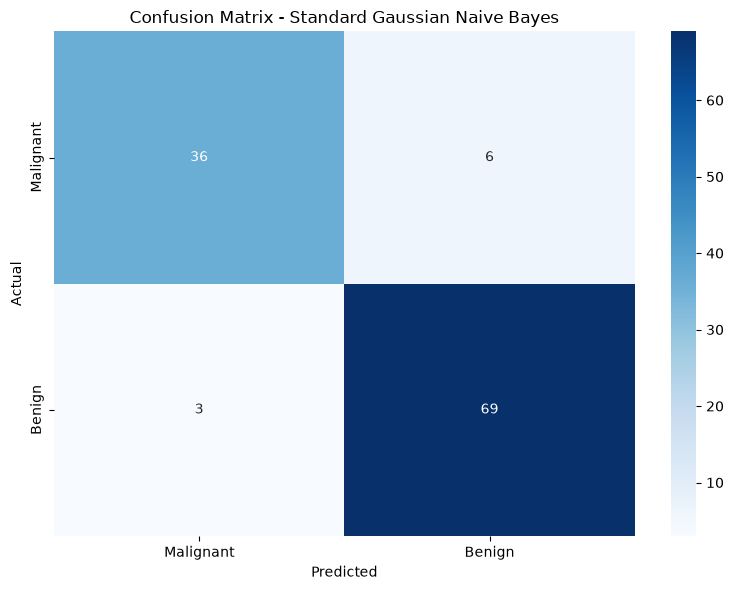


Confusion Matrix:
[[36  6]
 [ 3 69]]


In [6]:
# Average confusion matrix across all runs
avg_cm = np.mean(detail_cms, axis=0).astype(int)

TN = avg_cm[0, 0]
FP = avg_cm[0, 1]
FN = avg_cm[1, 0]
TP = avg_cm[1, 1]

custom_cm = np.array([
    [TP, FN],
    [FP, TN]
])

plt.figure(figsize=(8, 6))
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix - Standard Gaussian Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(custom_cm)

## 6. Save Baseline Results

In [7]:
import os
os.makedirs('output', exist_ok=True)
import json

parameters = {
    "model": "GaussianNB",
    "priors": "None (learned from data)",
    "var_smoothing": 1e-09
}

results_json = {
    "model_type": "Standard Gaussian Naive Bayes", 
    "accuracy": accuracy, 
    "confusion_matrix": avg_cm.tolist(), 
    "parameters": parameters
}
results_json.update(extra.means())

# Store baseline results for comparison with DP model
baseline_results = {
    'model': 'Standard GaussianNB',
    'accuracy': accuracy,
    'f1_score': f1,
    'precision': precision,
    'recall': recall,
    'roc_auc': roc_auc
}
baseline_results.update(extra.means())

# Save to CSV
baseline_df = pd.DataFrame([baseline_results])
baseline_df.to_csv('output/baseline_results.csv', index=False)

# Save to JSON file
with open('output/std_gnb_report.json', 'w') as f:
    json.dump(results_json, f, indent=4)

print("Results saved to 'output/std_gnb_report.json'")
print("Baseline results saved to 'output/baseline_results.csv'")
print("\nBaseline Performance Summary:")
print(baseline_df)

print("Added metrics:")
print(extra.describe())

Results saved to 'std_gnb_report.json'
Baseline results saved to 'baseline_results.csv'

Baseline Performance Summary:
                 model  accuracy  f1_score  precision    recall   roc_auc  \
0  Standard GaussianNB  0.921053  0.888889   0.923077  0.857143  0.989087   

   train_accuracy  balanced_accuracy  train_time  
0        0.945055           0.907738    0.000179  
Added metrics:
  Train Acc:      0.9451 ± 0.0000
  Balanced Acc:   0.9077 ± 0.0000
  AUROC:          0.9891 ± 0.0000
  Train Time (s): 0.0002 ± 0.0001
